# Challenge: Optimization on Other Datasets

## Download data from `yfinance`

In [1]:
import yfinance as yf

ticker = 'ZM'
df = yf.download(ticker, multi_level_index=False, auto_adjust=False)
df

/Users/neemaurassa/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-04-30,97.150002,97.150002,97.800003,93.489998,95.500000,7949200
2026-05-01,103.440002,103.440002,104.139999,98.809998,99.000000,5825900
2026-05-04,106.629997,106.629997,107.910004,103.209999,103.550003,5501900
2026-05-05,109.099998,109.099998,109.500000,105.330002,107.014999,4238500
2026-05-06,105.129997,105.129997,108.260002,104.610001,106.744003,6186800
2026-05-07,108.360001,108.360001,108.919998,105.330002,107.650002,4750600
2026-05-08,109.209999,109.209999,109.410004,105.220001,108.250000,3771200
2026-05-11,107.120003,107.120003,111.559998,105.459999,109.305000,4110300
2026-05-12,102.959999,102.959999,106.654999,102.220001,106.360001,4890100


## Preprocess the data

### Filter the date range

- Since 1 year ago at least

In [2]:
df = df.loc['2025-01-01':].copy()
df

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-04-30,97.150002,97.150002,97.800003,93.489998,95.500000,7949200
2026-05-01,103.440002,103.440002,104.139999,98.809998,99.000000,5825900
2026-05-04,106.629997,106.629997,107.910004,103.209999,103.550003,5501900
2026-05-05,109.099998,109.099998,109.500000,105.330002,107.014999,4238500
2026-05-06,105.129997,105.129997,108.260002,104.610001,106.744003,6186800
2026-05-07,108.360001,108.360001,108.919998,105.330002,107.650002,4750600
2026-05-08,109.209999,109.209999,109.410004,105.220001,108.250000,3771200
2026-05-11,107.120003,107.120003,111.559998,105.459999,109.305000,4110300
2026-05-12,102.959999,102.959999,106.654999,102.220001,106.360001,4890100


### Create the target variable

#### Percentage change

- Percentage change on `Adj Close` for tomorrow

In [3]:
df['change_tomorrow'] = df['Adj Close'].pct_change(-1)
df.change_tomorrow = df.change_tomorrow * -1
df.change_tomorrow = df.change_tomorrow * 100
df

,Adj Close,Close,High,Low,Open,Volume,change_tomorrow
Date,,,,,,,
2026-04-30,97.150002,97.150002,97.800003,93.489998,95.500000,7949200,6.080821
2026-05-01,103.440002,103.440002,104.139999,98.809998,99.000000,5825900,2.991649
2026-05-04,106.629997,106.629997,107.910004,103.209999,103.550003,5501900,2.263979
2026-05-05,109.099998,109.099998,109.500000,105.330002,107.014999,4238500,-3.776278
2026-05-06,105.129997,105.129997,108.260002,104.610001,106.744003,6186800,2.980808
2026-05-07,108.360001,108.360001,108.919998,105.330002,107.650002,4750600,0.778316
2026-05-08,109.209999,109.209999,109.410004,105.220001,108.250000,3771200,-1.951079
2026-05-11,107.120003,107.120003,111.559998,105.459999,109.305000,4110300,-4.040408
2026-05-12,102.959999,102.959999,106.654999,102.220001,106.360001,4890100,-0.517425


#### Remove rows with any missing data

In [4]:
df = df.dropna().copy()
df

,Adj Close,Close,High,Low,Open,Volume,change_tomorrow
Date,,,,,,,
2026-04-30,97.150002,97.150002,97.800003,93.489998,95.500000,7949200,6.080821
2026-05-01,103.440002,103.440002,104.139999,98.809998,99.000000,5825900,2.991649
2026-05-04,106.629997,106.629997,107.910004,103.209999,103.550003,5501900,2.263979
2026-05-05,109.099998,109.099998,109.500000,105.330002,107.014999,4238500,-3.776278
2026-05-06,105.129997,105.129997,108.260002,104.610001,106.744003,6186800,2.980808
2026-05-07,108.360001,108.360001,108.919998,105.330002,107.650002,4750600,0.778316
2026-05-08,109.209999,109.209999,109.410004,105.220001,108.250000,3771200,-1.951079
2026-05-11,107.120003,107.120003,111.559998,105.459999,109.305000,4110300,-4.040408
2026-05-12,102.959999,102.959999,106.654999,102.220001,106.360001,4890100,-0.517425


## Compute Machine Learning model

Proposal: Random Forest within `ensemble` module of `sklearn` library

In [5]:
from sklearn.ensemble import RandomForestRegressor

In [6]:
model = RandomForestRegressor(max_depth=20, random_state=42)

In [7]:
y = df.change_tomorrow
X = df.drop(columns='change_tomorrow')

In [8]:
model.fit(X, y)

RandomForestRegressor(max_depth=20, random_state=42)

In [9]:
model.score(X, y)

0.8734705543089429

## Parametrize & optimize the investment strategy

### Create Strategy class

In [10]:
from backtesting import Strategy

In [11]:
class Regression(Strategy):
    limit_buy = 1
    limit_sell = -5
    
    def init(self):
        self.model = model
        self.already_bought = False

    def next(self):
        explanatory_today = self.data.df.iloc[[-1], :]
        forecast_tomorrow = self.model.predict(explanatory_today)[0]
        
        if forecast_tomorrow > self.limit_buy and self.already_bought == False:
            self.buy()
            self.already_bought = True
        elif forecast_tomorrow < self.limit_sell and self.already_bought == True:
            self.sell()
            self.already_bought = False
        else:
            pass

### Create `Backtest` class

In [12]:
from backtesting import Backtest

In [13]:
bt = Backtest(
    X, Regression, cash=10000,
    commission=.002, exclusive_orders=True
)

### Optimize backtesting with multiple combinations

In [14]:
stats_skopt, heatmap, optimize_result = bt.optimize(
    limit_buy=[0, 10],
    limit_sell=[-10, 0],
    maximize='Return [%]',
    method='skopt',
    max_tries=500,
    random_state=0,
    return_heatmap=True,
    return_optimization=True)

/Users/neemaurassa/Library/Python/3.9/lib/python/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(2), np.int64(-2)] before, using random point [np.int64(10), np.int64(-8)]
  warnings.warn(
/Users/neemaurassa/Library/Python/3.9/lib/python/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(4), np.int64(-2)] before, using random point [np.int64(3), np.int64(-10)]
  warnings.warn(
/Users/neemaurassa/Library/Python/3.9/lib/python/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), np.int64(-2)] before, using random point [np.int64(9), np.int64(-6)]
  warnings.warn(
/Users/neemaurassa/Library/Python/3.9/lib/python/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(1), np.int64(-2)] before, using random point [np.int64(9), np.int64(-1)]
  warni

### Which are the best values for the parameters?

In [15]:
import numpy as np

In [16]:
dff = heatmap.reset_index()
dff = dff.pivot(index='limit_buy', columns='limit_sell', values='Return [%]')

dff.sort_index(axis=1, ascending=False)\
    .style.format(precision=0)\
    .background_gradient(vmin=np.nanmin(dff), vmax=np.nanmax(dff))\
    .highlight_null(props='background-color: transparent; color: transparent')

limit_sell,0,-1,-2,-3,-4,-5,-6,-7,-8,-9,-10
limit_buy,,,,,,,,,,,
0,6,5,27,11,nan,-4,-4,-4,-4,-4,nan
1,5,4,26,11,-4,-4,-4,-4,-4,-4,-4
2,1,nan,3,-11,-7,-7,-7,nan,-7,-7,nan
3,1,1,1,-8,-8,-8,-8,-8,-8,-8,-8
4,1,1,1,-8,-8,nan,-8,nan,-8,-8,-8
5,1,1,1,-8,nan,-8,-8,-8,-8,-8,-8
6,1,1,1,-8,nan,-8,nan,-8,-8,-8,-8
7,0,nan,0,nan,nan,0,0,0,0,0,nan
8,nan,nan,0,0,0,0,0,nan,0,nan,0


### How to interpret smart optimization?

#### Number of evaluations

https://kernc.github.io/backtesting.py/doc/examples/Parameter%20Heatmap%20&%20Optimization.html

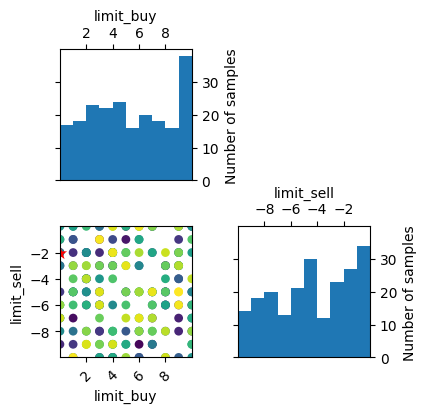

In [17]:
from skopt.plots import plot_evaluations

_ = plot_evaluations(optimize_result, bins=10)

#### Density

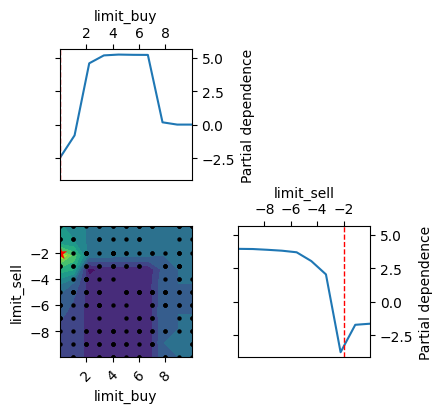

In [18]:
from skopt.plots import plot_objective

_ = plot_objective(optimize_result, n_points=10)

## Continue with the tutorials on the following chapter

> Backtest the investment strategy on a validation set.

Next chapter → [The Overfitting Problem in Backtesting]()

![](<src/09_Table_The Overfitting.png>)